In [1]:
import sys
sys.path.append('../')
from ArchVelo import *

In [2]:
import pickle
import warnings
warnings.filterwarnings("ignore")
from scipy.cluster.hierarchy import cut_tree, linkage
from sklearn.metrics import silhouette_score as ss

In [4]:
num_comps = 9

In [6]:
data_outdir = 'processed_data/'
model_outdir = 'modeling_results/'
#model_outdir = '../../ArchVelo_draft_HSC/modeling_results/no_cc_interc_scale_1500/9_comps/'

In [7]:
import os
fig_outdir = 'figures/'
os.makedirs(fig_outdir, exist_ok = True)


# Read in models for benchmarks

In [8]:
wcs = [np.round(wc, 1) for wc in np.linspace(0,1,11)]

In [9]:
adata_results = {}
for wc in wcs:
    adata_results[wc] = sc.read_h5ad(model_outdir+'multivelo_result_weight_c_'+str(wc)+'.h5ad')

In [10]:
archvelo_results = {}
for wc in wcs:
    f = open(model_outdir+'archevelo_results_weight_c_'+str(wc)+'.p', 'rb')
    archvelo_results[wc] = pickle.load(f)
    f.close()

In [11]:
scvelo_result = sc.read_h5ad(model_outdir+'scvelo_result.h5ad')

In [12]:
f = open(model_outdir+'top_lik.p', 'rb')
top_lik = pickle.load(f)
f.close()
rel_genes = top_lik
n_genes = len(rel_genes)

In [13]:
times = {}

In [14]:
times['MultiVelo'] = {}
for wc in wcs:
    
    times['MultiVelo'][wc] = adata_results[wc][:, rel_genes].layers['fit_t']
    times['MultiVelo'][wc] = pd.DataFrame(times['MultiVelo'][wc], columns = rel_genes)

In [15]:
times['ArchVelo'] = {}
for wc in wcs:
    times['ArchVelo'][wc] = np.concatenate([np.ravel(archvelo_results[wc][i][1]).reshape(-1,1) for i in range(n_genes)], 1)
    times['ArchVelo'][wc] = pd.DataFrame(times['ArchVelo'][wc], columns =
                         rel_genes)


In [16]:
times['scVelo'] = {}
for wc in wcs:
    if wc == 0:
        times['scVelo'][wc] = scvelo_result[:, rel_genes].layers['fit_t']
        times['scVelo'][wc] = pd.DataFrame(times['scVelo'][wc], columns =
                         rel_genes)
    else:
        times['scVelo'][wc] = times['scVelo'][0]

In [17]:
methods_multi = ['MultiVelo', 'ArchVelo']
methods = ['scVelo', 'MultiVelo', 'ArchVelo']

In [18]:
corrs = {}
for method in methods_multi:
    corrs[method] = {}
    for wc in wcs:
        corrs[method][wc] = times[method][wc].corr(method = 'spearman').fillna(0)


In [19]:
for method in ['scVelo']:
    corrs[method] = {}
    for wc in wcs:
        if wc == 0:
            corrs[method][wc] = times[method][wc].corr(method = 'spearman').fillna(0)
        else:
            corrs[method][wc] = corrs[method][0]

In [20]:
import pickle
f = open(model_outdir+'corrs.p', 'wb')
pickle.dump(corrs, f)
f.close()

# Latent time plots

In [21]:
multi_default = 0.6
arch_default = 0.3

In [22]:
all_corrs = corrs['ArchVelo'][arch_default]
all_original_corrs = corrs['MultiVelo'][multi_default]

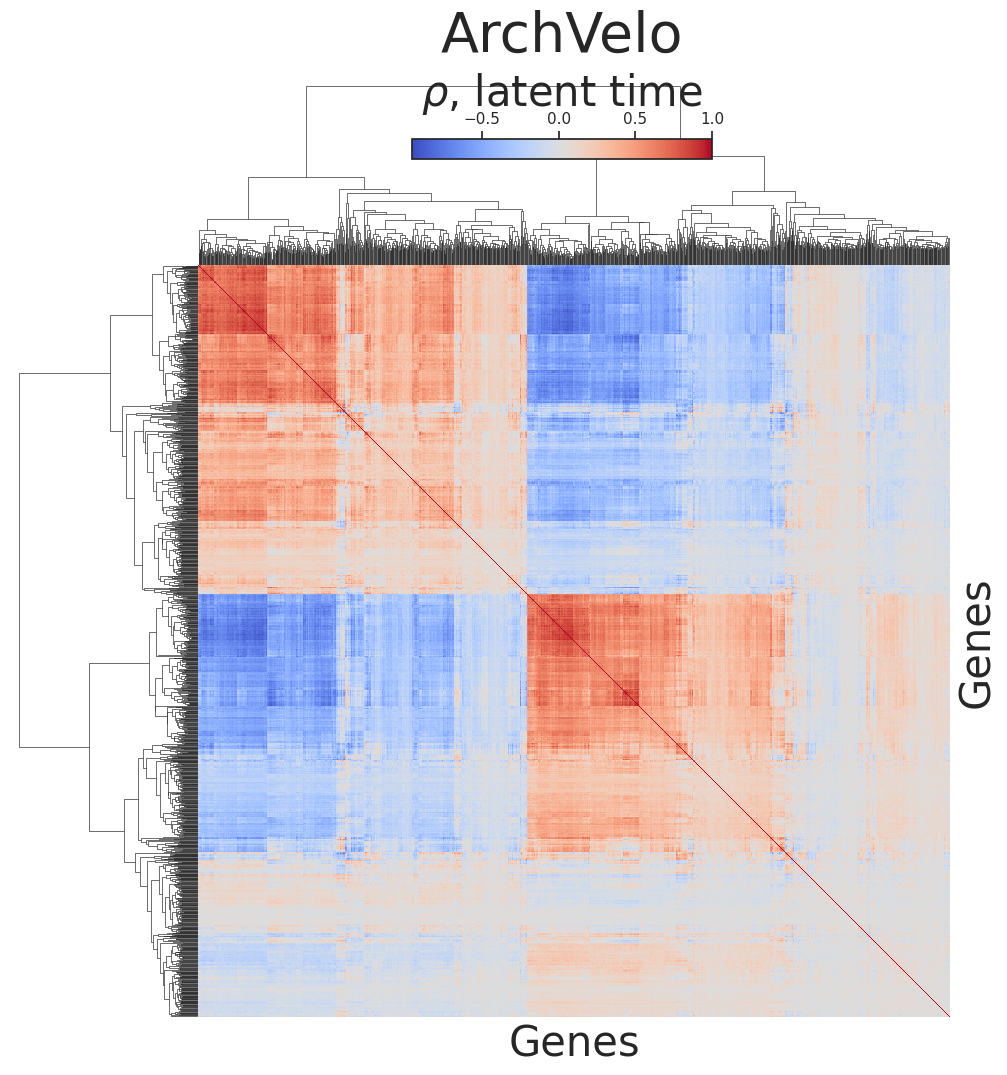

In [23]:
sns.set(style = 'white', font_scale = 1.)
g = sns.clustermap(all_corrs, 
                   method = 'average', 
                   metric = 'euclidean',
                   #row_colors = sns.color_palette('nipy_spectral', 3, as_cmap = True)(clusts_original/3),
                   cmap = 'coolwarm', 
                   center = 0,
                  #cbar_pos=(0.05, 0.65, 0.03, 0.3),
                  xticklabels = 0, yticklabels = 0, 
                  cbar_pos = None)
g.ax_heatmap.set_xlabel('Genes', fontsize = 30)
g.ax_heatmap.set_ylabel('Genes', fontsize = 30)

# Add horizontal colorbar manually
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create a new axis below the heatmap
divider = make_axes_locatable(g.ax_heatmap)
#cax = divider.append_axes("top", size="5%", pad=0)

# Add the colorbar
cax = g.fig.add_axes([0.42, 0.9, 0.3, 0.02]) 
norm = plt.Normalize(vmin=all_corrs.values.min(), vmax=all_corrs.values.max())
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
cb = g.fig.colorbar(sm, cax=cax, orientation='horizontal')

cb.set_label(r'$\rho$, latent time', fontsize = 30)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')

#plt.tight_layout()
plt.suptitle('ArchVelo', fontsize = 40, y = 1.05, x = 0.57)
plt.savefig(fig_outdir+'Latent_time_corrs_ArchVelo.png', dpi = 300, bbox_inches='tight', transparent = True)
#plt.savefig(fig_outdir+'Latent_time_corrs_ArchVelo.svg', dpi = 300)

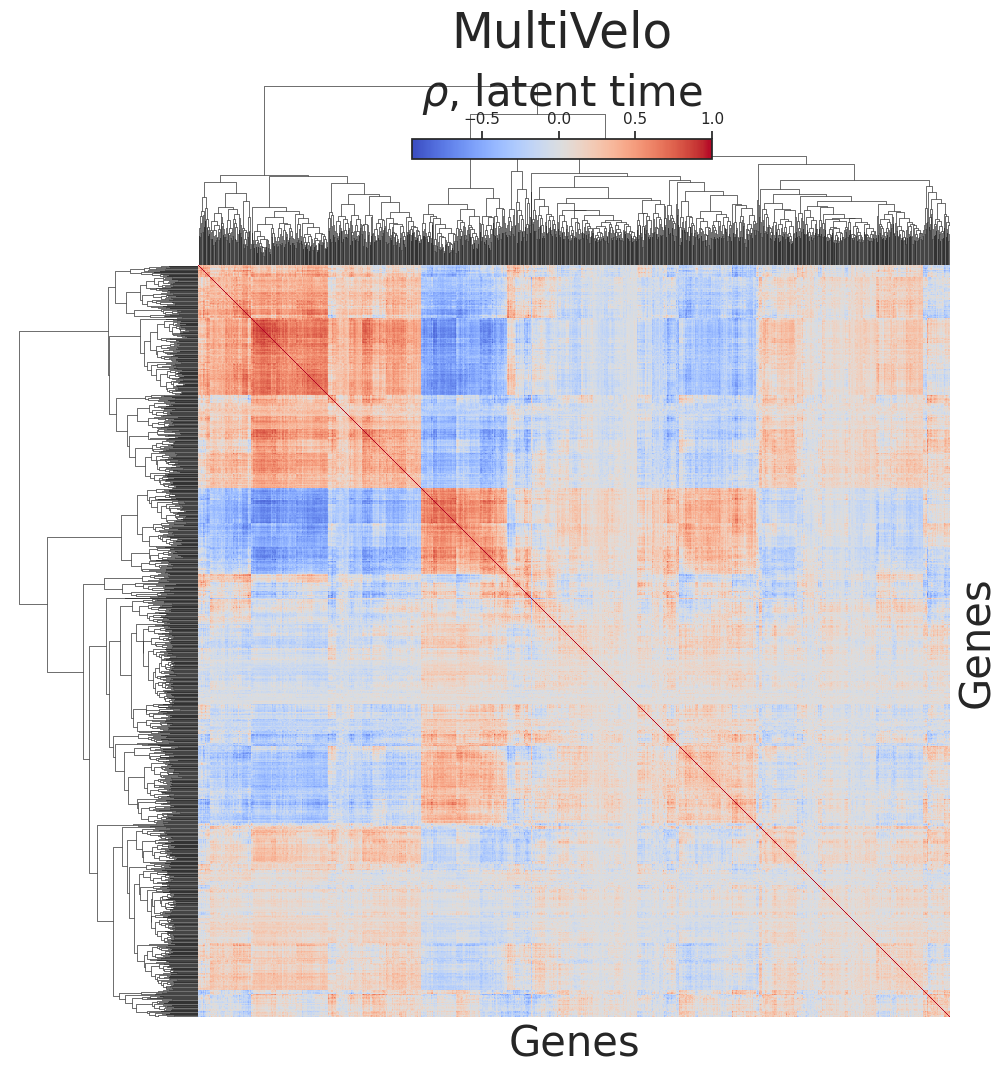

In [24]:
sns.set(style = 'white', font_scale = 1.)
g = sns.clustermap(all_original_corrs, 
               method = 'average', 
               metric = 'euclidean',
              cmap = 'coolwarm', 
               center = 0,
#                   cbar_pos=(0.05, 0.8, 0.03, 0.2))
# g.ax_heatmap.set_xlabel('Gene', fontsize = 20)
# g.ax_heatmap.set_ylabel('Gene', fontsize = 20)
# g.cax.set_ylabel(r'$\rho$, latent time', 
#                  rotation = 90, 
#                  fontsize = 20
#                )  # Use 'left', 'right', or 'center'
# g.cax.yaxis.set_label_position('left')

xticklabels = 0, yticklabels = 0, 
                  cbar_pos = None)
g.ax_heatmap.set_xlabel('Genes', fontsize = 30)
g.ax_heatmap.set_ylabel('Genes', fontsize = 30)

# Add horizontal colorbar manually
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create a new axis below the heatmap
divider = make_axes_locatable(g.ax_heatmap)
#cax = divider.append_axes("top", size="5%", pad=0)

# Add the colorbar
cax = g.fig.add_axes([0.42, 0.9, 0.3, 0.02]) 
norm = plt.Normalize(vmin=all_corrs.values.min(), vmax=all_corrs.values.max())
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
cb = g.fig.colorbar(sm, cax=cax, orientation='horizontal')

cb.set_label(r'$\rho$, latent time', fontsize = 30)
cax.xaxis.set_label_position('top')
cax.xaxis.set_ticks_position('top')

plt.suptitle('MultiVelo', fontsize = 35, y = 1.05, x = 0.57)
plt.savefig(fig_outdir+'Latent_time_corrs_MultiVelo.png', dpi = 300, bbox_inches='tight', transparent = True)
#plt.savefig(fig_outdir+'Latent_time_corrs_MultiVelo.svg', dpi = 300)

# Benchmark

## Silhouette scores

In [25]:
import pickle
f = open(model_outdir+'corrs.p', 'rb')
corrs = pickle.load(f)
f.close()

In [26]:
linestyles = dict(zip(methods, ['solid']*3))

In [27]:
np.random.seed(57)

In [28]:
sil_scores = {}
clusts = {}
for method in methods_multi:
    sil_scores[method] = {}
    clusts[method] = {}
    ls = linestyles[method]
    for wc in wcs:
        sil_scores[method][wc] = {}
        clusts[method][wc] = {}
        for i in range(2,20):
            clusts[method][wc][i] = cut_tree(linkage(corrs[method][wc], method='average', metric='euclidean'), n_clusters = i)
            sil_scores[method][wc][i] = ss(corrs[method][wc], clusts[method][wc][i])
        sil_scores[method][wc] = pd.Series(sil_scores[method][wc])

In [29]:
for method in ['scVelo']:
    sil_scores[method] = {}
    clusts[method] = {}
    for wc in wcs:
        sil_scores[method][wc] = {}
        clusts[method][wc] = {}
        if wc == 0:
            for i in range(2,20):
                clusts[method][wc][i] = cut_tree(linkage(corrs[method][wc], method='average', metric='euclidean'), n_clusters = i)
                sil_scores[method][wc][i] = ss(corrs[method][wc], clusts[method][wc][i])
        else:
            #placeholder
            for i in range(2,20):
                sil_scores[method][wc][i] = sil_scores[method][0][i]
        sil_scores[method][wc] = pd.Series(sil_scores[method][wc])

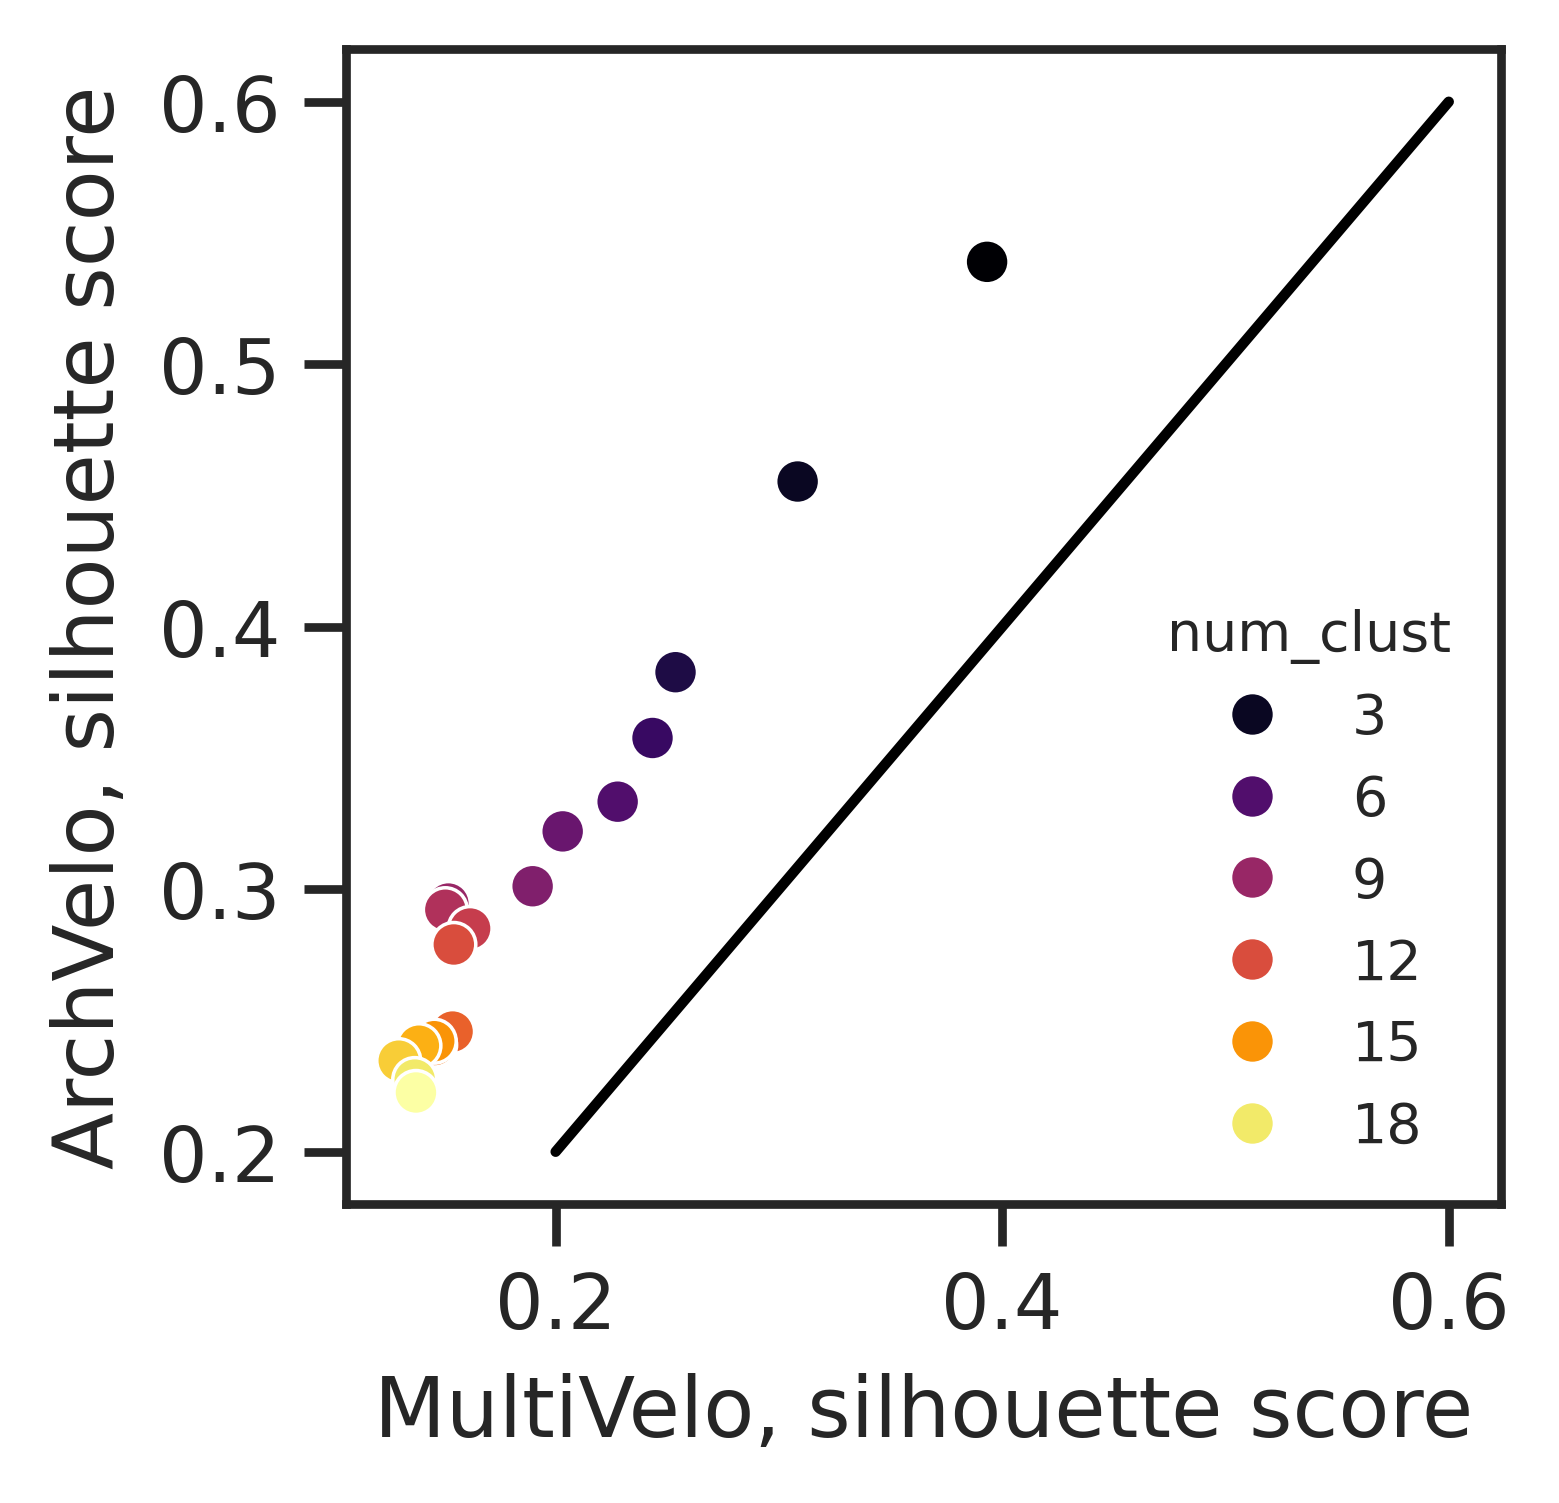

In [56]:
sns.set(style = 'ticks', font_scale = 1.)
fig, ax = plt.subplots(1,1, dpi = 500, figsize = (4,3))
ax.set_box_aspect(1)
# all_ss = pd.concat([pd.Series(sil_scores['MultiVelo'][0.6]),pd.Series(sil_scores['ArchVelo'][0.3])], axis = 1).reset_index()
# all_ss.columns = ['
xx = pd.Series(sil_scores['MultiVelo'][0.6])
yy = pd.Series(sil_scores['ArchVelo'][0.3])
g = sns.scatterplot(x = xx, 
            y = yy,
           ax = ax, s = 40,
               hue = range(2,20),
                   palette = 'inferno')
# eps = 0.02
# x0+=eps
# y0+=eps
# ax.text(x0,y0,'Satb2', fontsize = 5)
plt.legend(frameon = False, title = 'num_clust', 
           fontsize = 8, title_fontsize = 8, loc = 'lower right')
plt.ylabel('ArchVelo, silhouette score')
plt.xlabel('MultiVelo, silhouette score')
plt.plot([0.2, 0.6], [0.2, 0.6], c = 'black')
plt.savefig(fig_outdir+'ss_per_clusts.png', dpi = 500, transparent = True)
plt.savefig(fig_outdir+'ss_per_clusts.svg', dpi = 500, transparent = True)

In [57]:
from scipy.stats import wilcoxon
wilcoxon(x = yy.dropna(), 
         y = xx.loc[yy.dropna().index],
         zero_method='wilcox', 
         correction=False)#, alternative='greater')

WilcoxonResult(statistic=0.0, pvalue=7.62939453125e-06)

In [32]:
mean_sil_scores = {}
for method in methods:
    mean_sil_scores[method] = {}
    for wc in wcs:
        mean_sil_scores[method][wc] = np.mean(sil_scores[method][wc])

In [33]:
mss = pd.DataFrame(mean_sil_scores)
mss.columns.names = ['method']
mss.index.names = ['$W_c$']
mss = mss.stack().reset_index()
mss.columns = ['$W_c$', 'method', 'latent_time_silhouette']

In [34]:
import pickle
f = open(model_outdir+'mss.p', 'wb')
pickle.dump(mss, f)
f.close()

## Likelihoods

### Create avels for every wc

In [35]:
adata_rna = sc.read_h5ad(data_outdir+'adata_rna.h5ad')
adata_atac = sc.read_h5ad(data_outdir+'adata_atac.h5ad')
full_res_denoised = anndata.read_h5ad(model_outdir+'multivelo_result_denoised_chrom.h5ad')
smooth_arch = sc.read_h5ad(model_outdir+'arches.h5ad')
gene_weights = pd.read_csv(model_outdir+'gene_weights.csv', index_col = [0])
min_c, max_c = extract_minmax(smooth_arch)    

In [ ]:
'hello'

In [36]:
avels = {}
for wc in wcs:   
    av_pars = archvelo_results[wc]
    avel = velocity_result(adata_rna.copy(), 
              full_res_denoised.copy(),
              gene_weights,
              min_c, max_c, 
              av_pars,)
    # Likelihoods are calculated on MultiVelo-filtered cells
    avel.var['fit_likelihood'] = np.nan
    for g in avel.var_names:    
        liks = calc_lik_ArchVelo(g,
                      adata_atac = adata_atac,
                      avel = avel)
        avel.var['fit_likelihood'].loc[g] = liks[0]
    avels[wc] = avel.copy()

### Compare likelihoods

In [37]:
# Here we give maximal advantage to MultiVelo, with
# all likelihoods are calculated on the same set of MultiVelo-filtered cells
liks = {}
for method in methods_multi:
    liks[method] = {}  
    for wc in wcs:
        liks[method][wc] = {}
        for g in rel_genes:
            if method == 'MultiVelo':
                cur = adata_results[wc][:, g]
                liks[method][wc][g] = cur.var['fit_likelihood'][0]/cur.var['fit_likelihood_c'][0]
            else:
                if g in avels[wc].var_names:
                    liks[method][wc][g] = avels[wc].var['fit_likelihood'].loc[g]
                else:
                    liks[method][wc][g] = np.nan


In [38]:
for method in ['scVelo']:
    liks[method] = {}  
    for wc in wcs:#np.linspace(0,1,11):
        if wc == 0:
            liks[method][wc] = {}
            for g in rel_genes:
                liks[method][wc][g] = calc_lik_scvelo(g,
                                                      adata_atac = adata_atac,
                                                      model_to_use= scvelo_result, 
                                                      plot = False)[0]
        else:
            liks[method][wc] = liks[method][0]
            


In [39]:
import pickle
f = open(model_outdir+'likelihoods.p', 'wb')
pickle.dump(liks, f)
f.close()

### Errors

In [40]:
import pickle
f = open(model_outdir+'likelihoods.p', 'rb')
liks = pickle.load(f)
f.close()

In [41]:
import pickle
f = open(model_outdir+'mss.p', 'rb')
mss = pickle.load(f)
f.close()

In [42]:
multi_default = 0.6
arch_default = 0.3

In [43]:
for method in methods:
    for wc in wcs:#np.linspace(0,1,11):
        liks[method][wc] = pd.Series(liks[method][wc])

In [44]:
mean_liks = {}
for method in methods:
    mean_liks[method] = {}
    for wc in wcs:
        mean_liks[method][wc] = np.mean(np.log1p(liks[method][wc]))#np.mean(np.log1p(us_liks[method][wc]))

In [45]:
mlks = pd.DataFrame(mean_liks)
mlks.columns.names = ['method']
mlks.index.names = ['$W_c$']
mlks = mlks.stack().reset_index()
mlks.columns = ['$W_c$', 'method', 'mean(u-s loglikelihood)']

In [46]:
#both = pd.concat([mss, mers.iloc[:, -1], mlks.iloc[:, -1]], axis = 1)
both = pd.concat([mss, mlks.iloc[:, -1]], axis = 1)

In [47]:
both_multi = both.loc[both['method'].isin(methods_multi),:]

In [49]:
'hello'

'hello'

In [50]:
scvelo_default = both.loc[both.iloc[:,0] == 0].query('method == "scVelo"')
multivelo_default = both.loc[both.iloc[:,0] == multi_default].query('method == "MultiVelo"')
archvelo_default = both.loc[both.iloc[:,0] == arch_default].query('method == "ArchVelo"')
both_defaults = pd.concat([scvelo_default,
                           multivelo_default,
                           archvelo_default], axis = 0)

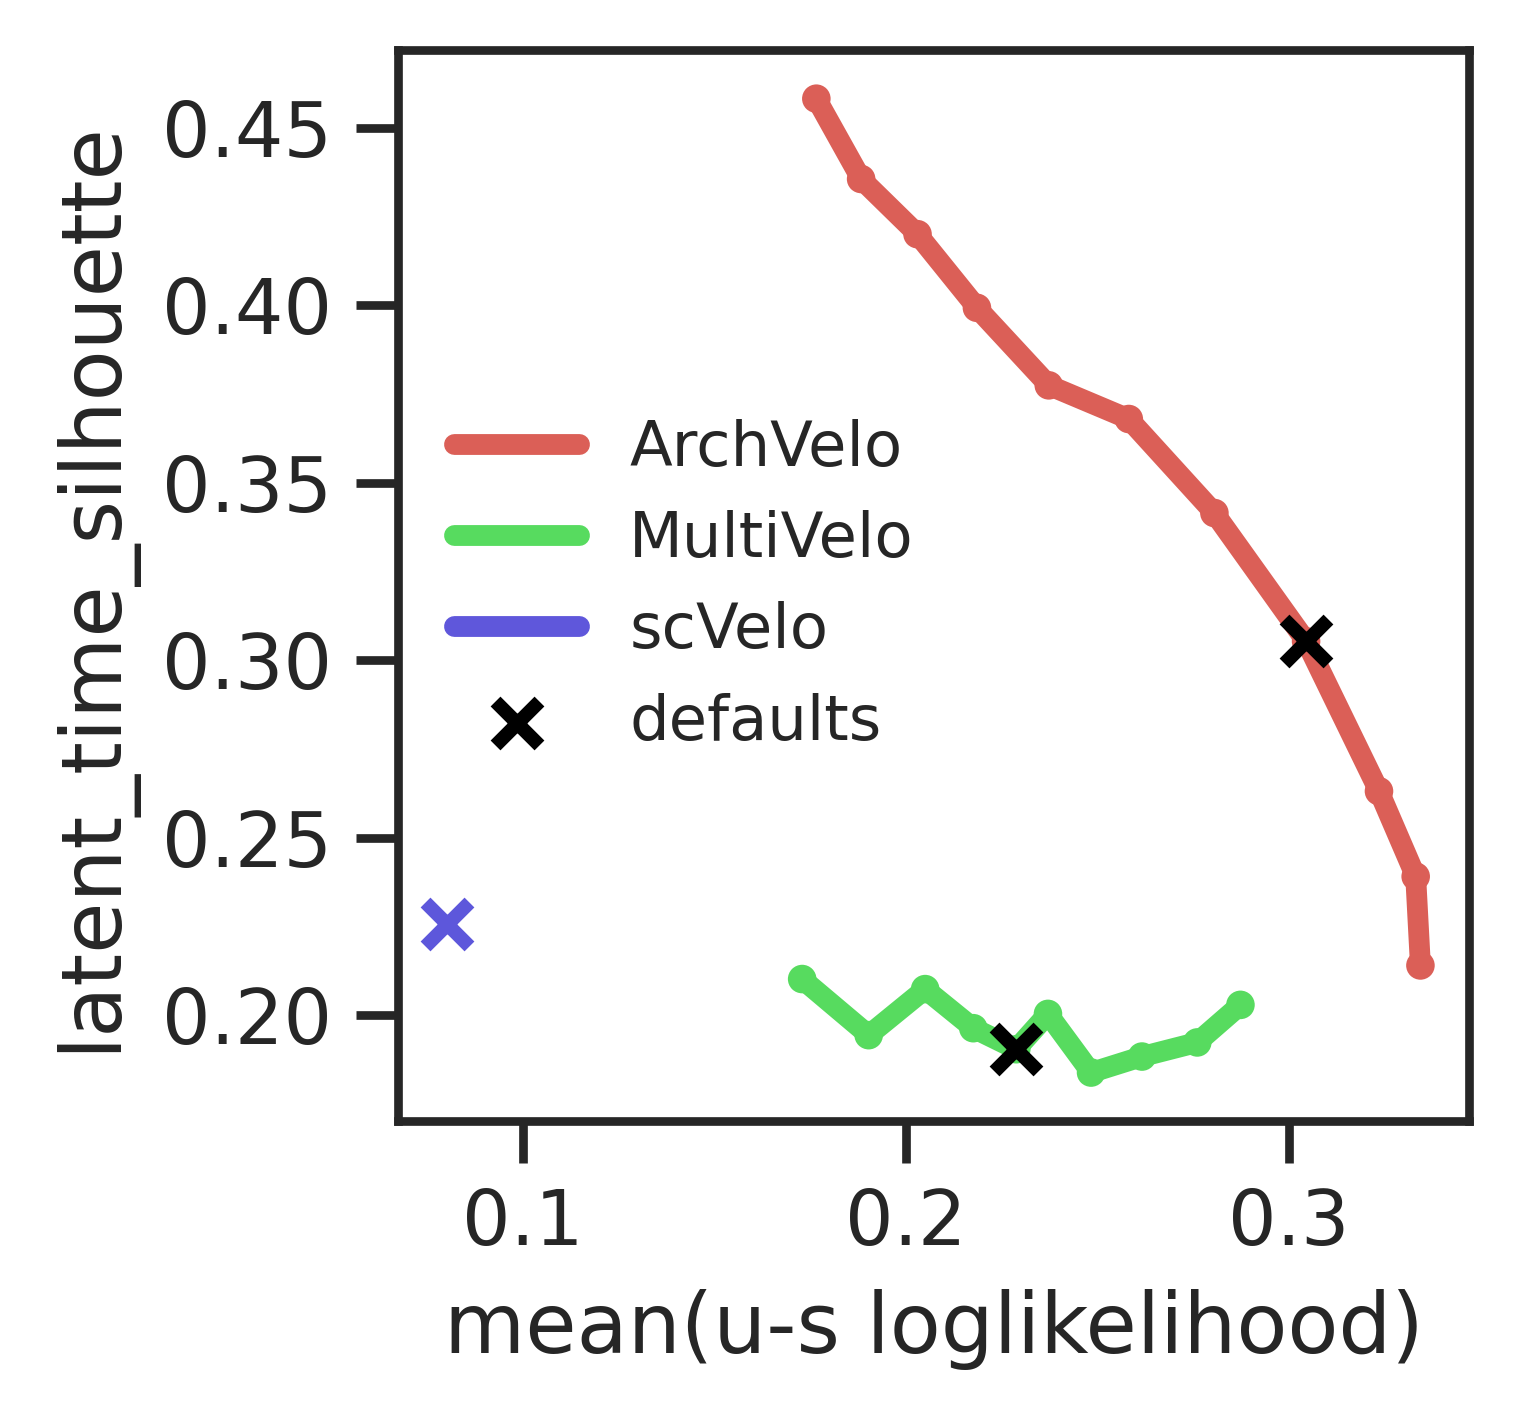

In [52]:
sns.set(style = 'ticks', font_scale = 1.)
fig, ax = plt.subplots(1,1, dpi = 500, figsize = (6,3))
ax.set_box_aspect(1)
sns.lineplot(data = both_multi, 
             y = 'latent_time_silhouette',
             x = 'mean(u-s loglikelihood)',
             hue = 'method',
             palette = 'hls',
             hue_order = methods[::-1],
             lw = 3, 
             sort = False)
sns.scatterplot(data = both_multi, 
             y = 'latent_time_silhouette',
             x = 'mean(u-s loglikelihood)',
             hue = 'method',
             palette = 'hls',
             hue_order = methods[::-1], 
                legend = None,
               s = 20)
             #style_order = methods[::-1],
             #style = 'method', lw = 3)
sns.scatterplot(data = both_multi.loc[both_multi['$W_c$']==0.6].loc[both_multi['method']!='ArchVelo'], 
         y = 'latent_time_silhouette',
         x = 'mean(u-s loglikelihood)',
         marker = 'x',
         color = 'black',
         s = 40,lw = 2,
         legend = None, zorder=7)
sns.scatterplot(data = both_multi.loc[both_multi['$W_c$']==0.3].loc[both_multi['method']=='ArchVelo'], 
         y = 'latent_time_silhouette',
         x = 'mean(u-s loglikelihood)',
         marker = 'x',
         color = 'black',
         s = 40,lw = 2,
         zorder=7, label = 'defaults')
sns.scatterplot(data = both.loc[both['$W_c$']==0].query('method == "scVelo"'), 
         y = 'latent_time_silhouette',
         x = 'mean(u-s loglikelihood)',
         marker = 'x',
         color = sns.color_palette('hls', 3, as_cmap = True)(2/3),
         s = 40,lw = 2,
         legend = None, zorder=7)

plt.legend(fontsize = 9, frameon = False)
#plt.title('HSC', fontsize = 20, y = 0.99)
plt.tight_layout()
plt.savefig(fig_outdir+'benchmark_curves_with_scvelo.png', dpi = 500, transparent = True)
plt.savefig(fig_outdir+'benchmark_curves_with_scvelo.svg', dpi = 500, transparent = True)

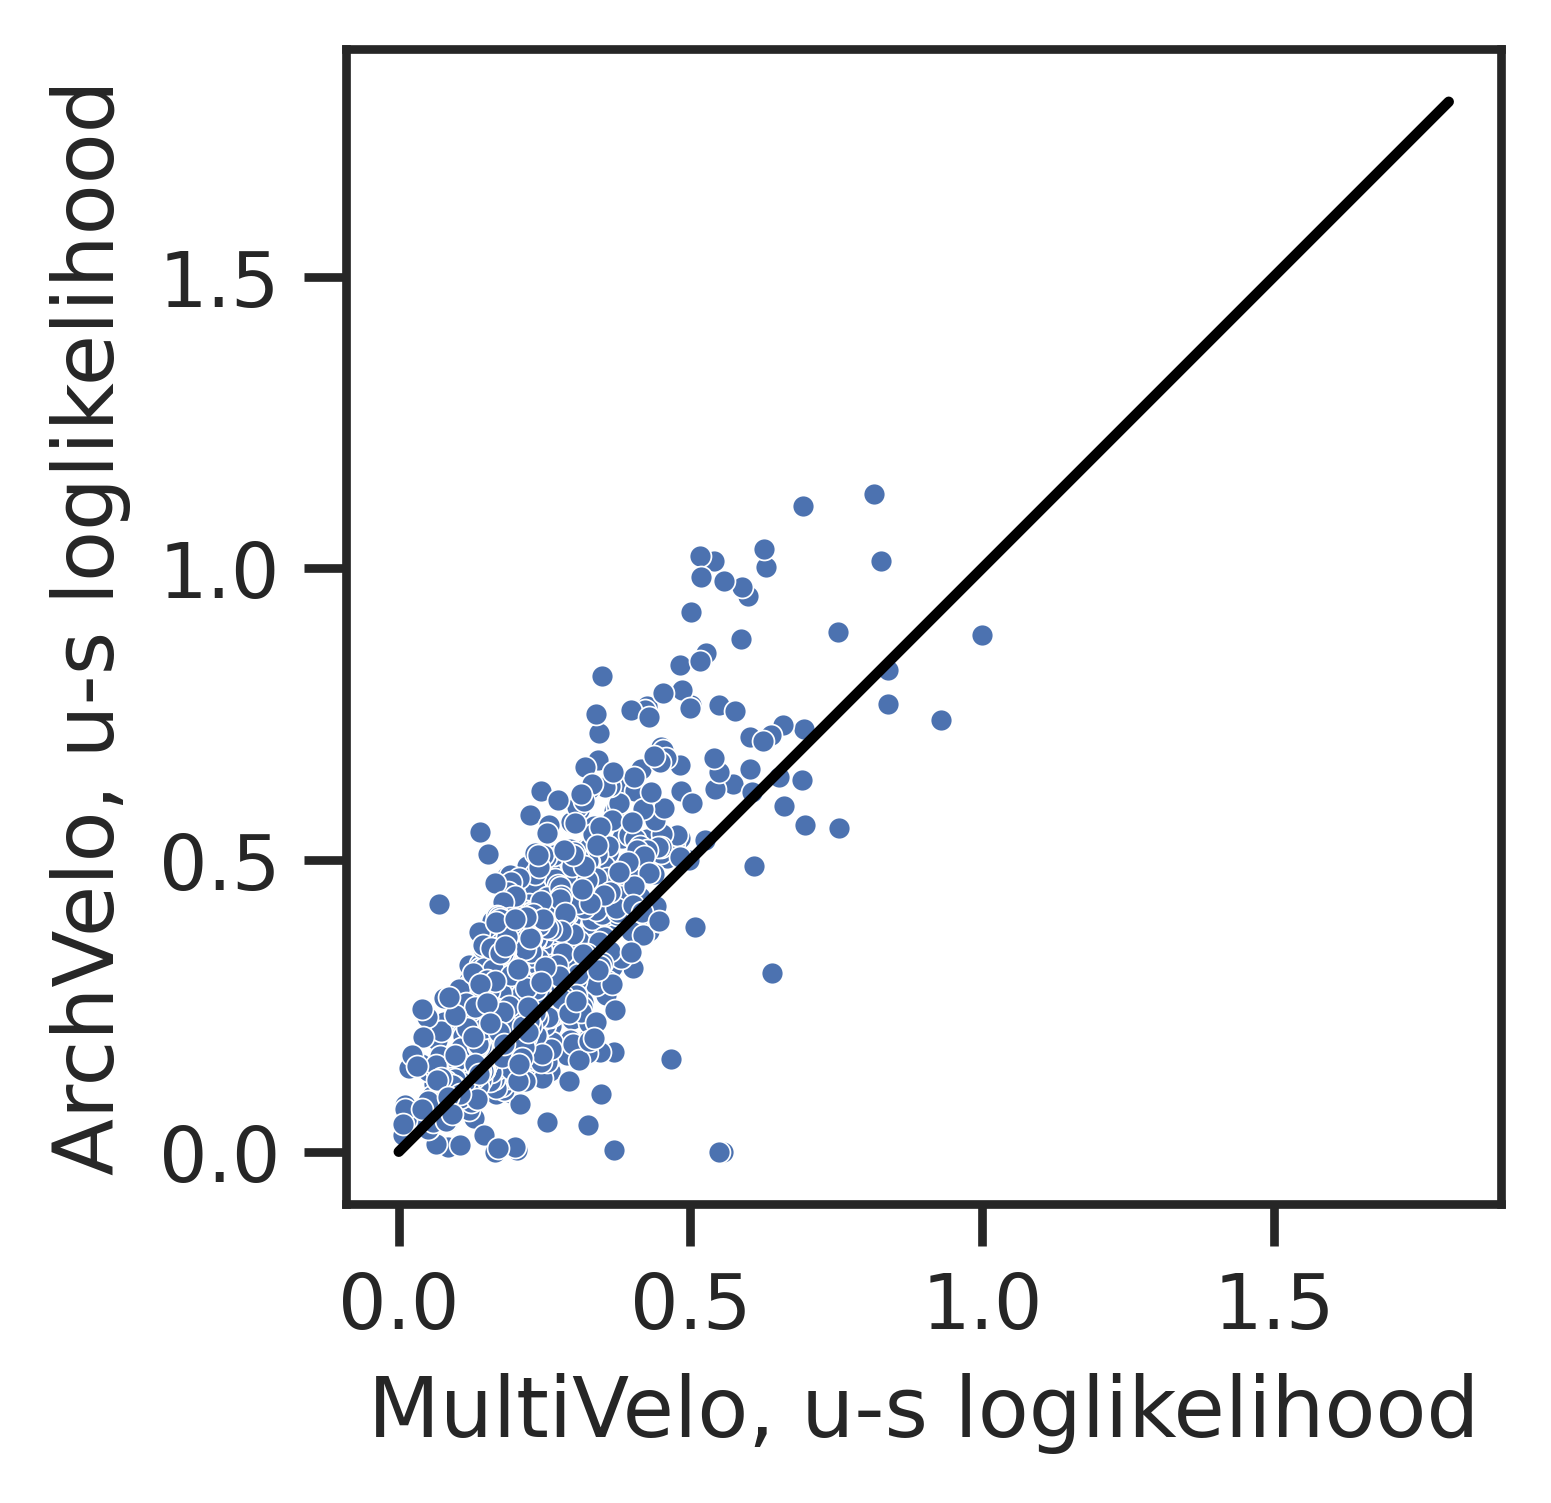

In [53]:
sns.set(style = 'ticks', font_scale = 1.)
fig, ax = plt.subplots(1,1, dpi = 500, figsize = (4,3))
ax.set_box_aspect(1)
xx = np.log1p(pd.Series(liks['MultiVelo'][multi_default]))
yy = np.log1p(pd.Series(liks['ArchVelo'][arch_default]))
sns.scatterplot(x = xx, 
                y = yy,
                ax = ax, 
                s = 10)
plt.ylabel('ArchVelo, u-s loglikelihood')
plt.xlabel('MultiVelo, u-s loglikelihood')
plt.plot([0, 1.8], [0, 1.8], c = 'black')
plt.savefig(fig_outdir+'loglik_per_gene.png', dpi = 500)
plt.savefig(fig_outdir+'loglik_per_gene.svg', dpi = 500)

In [55]:
from scipy.stats import wilcoxon
wilcoxon(x = yy.dropna(), 
         y = xx.loc[yy.dropna().index],
         zero_method='wilcox', 
         correction=False)#, alternative='greater')

WilcoxonResult(statistic=112304.0, pvalue=3.8666271634964897e-118)